<a href="https://colab.research.google.com/github/jose-esquivel-dev/Analitica_de_Datos/blob/main/Practica_2/AD_U2_Practica_2_EsquivelJose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTITUTO TECNOLOGICO DE CIUDAD JUAREZ**

**Ciencia y analítica de datos**

MODELOS DE APRENDIZAJE


**ACTIVIDAD 2**
Exploración de datos

---

*   NOMBRE: Jose Enrique Esquivel Torres

---


*   NO. CONTROL: 23110182

-------

# CODIGO PARA ACCEDER A NUESTRO DRIVE

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# IMPORTA LAS LIBRERIAS NECESARIAS

In [4]:
#libreria manipulacion de datos
import pandas as pd

#libreria para calculos numericos y estadisticos
import numpy as np

#Librerias para graficar
import matplotlib.pyplot as plt
import seaborn as sns


# CONVIERTE ARCHIVO CSV A TIPO DataFrame (df)

In [5]:
credit_df = pd.read_csv('/content/drive/MyDrive/T-Escuela_8/Analitica de Datos/Practicas_Colab/U2/Actividad_2/credit_risk_dataset.csv')
credit_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


----

# **Parte 1**. Análisis descriptivo (univariante)

1. Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas cualitativas?

<font color="orange">ESCRIBE AQUI TU RESPUESTA</FONT>

In [6]:
#.info()muestra la informacion del dataframe numero de columnas y del tipo de dato de cada una de las columnas
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
# Creamos un diccionario con la información
diccionario_datos = {
    "Variable": credit_df.select_dtypes('number').columns,
    "Descripción": [
        "Edad del solicitante en años",
        "Ingreso anual del solicitante",
        "Antigüedad laboral en años",
        "Monto del préstamo solicitado",
        "Tasa de interés del préstamo",
        "Estado del préstamo (0: pagado, 1: impago)",
        "Porcentaje del ingreso que representa el préstamo",
        "Años de historial en el buró de crédito"
    ]
}

# Lo convertimos a DataFrame para que se vea como una tabla bonita en Jupyter
tabla_variables = pd.DataFrame(diccionario_datos)
display(tabla_variables)

,Variable,Descripción
0,person_age,Edad del solicitante en años
1,person_income,Ingreso anual del solicitante
2,person_emp_length,Antigüedad laboral en años
3,loan_amnt,Monto del préstamo solicitado
4,loan_int_rate,Tasa de interés del préstamo
5,loan_status,"Estado del préstamo (0: pagado, 1: impago)"
6,loan_percent_income,Porcentaje del ingreso que representa el préstamo
7,cb_person_cred_hist_length,Años de historial en el buró de crédito


 2. Determina el porcentaje de valores faltantes por columna.

In [8]:
#.isna() revisa si existen valores nulos
credit_df.isna()
#.mean() calcula promedio
round(credit_df.isna().mean()*100,2)

,0
person_age,0.00
person_income,0.00
person_home_ownership,0.00
person_emp_length,2.75
loan_intent,0.00
loan_grade,0.00
loan_amnt,0.00
loan_int_rate,9.56
loan_status,0.00
loan_percent_income,0.00


Como podemos observar en la tabla anterior solo existen dos columnas con valores nulos, gracias a la funcion `round(credit_df.isna().mean()*100,2)`. La primera es la columna `person_emp_length` la cual cuenta con un **2.75%** en promedio de datos vacios, luego tenemos `loan_int_rate` la cual cuenta con un **9.56%** en promedio de datos vacios.

# Análisis de variables numéricas

3. Obtén las siguientes estadísticas descriptivas para todas las variables numéricas:
*   Tendencia central (media, mediana)
*   Dispersión o variabilidad (min, max, desviación estándar, cuartiles)
*   Forma (asimetría y curtosis)
*   Clasifica las variables `person_age` y `loan_in_rate` según los valores observados de asimetría y curtosis

**NOTA**. Recuerda que muchas de estas estadísticas, puedes obtenerlas utilizando la función `describe()` y que la mediana está representada en el 2do cuartil (50%)

In [9]:
round(credit_df.describe(),2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [10]:
credit_df.select_dtypes('number').median()

,0
person_age,26.00
person_income,55000.00
person_emp_length,4.00
loan_amnt,8000.00
loan_int_rate,10.99
loan_status,0.00
loan_percent_income,0.15
cb_person_cred_hist_length,4.00


In [11]:
credit_df.select_dtypes('number').skew()

,0
person_age,2.581393
person_income,32.865349
person_emp_length,2.614455
loan_amnt,1.192477
loan_int_rate,0.208550
loan_status,1.364888
loan_percent_income,1.064669
cb_person_cred_hist_length,1.661790


In [12]:
credit_df.select_dtypes('number').kurt()

,0
person_age,18.560825
person_income,2693.272776
person_emp_length,43.722338
loan_amnt,1.423565
loan_int_rate,-0.671609
loan_status,-0.137088
loan_percent_income,1.223687
cb_person_cred_hist_length,3.716194


In [13]:
credit_df.select_dtypes('number').min()

,0
person_age,20.00
person_income,4000.00
person_emp_length,0.00
loan_amnt,500.00
loan_int_rate,5.42
loan_status,0.00
loan_percent_income,0.00
cb_person_cred_hist_length,2.00


In [14]:
credit_df.select_dtypes('number').max()

,0
person_age,144.00
person_income,6000000.00
person_emp_length,123.00
loan_amnt,35000.00
loan_int_rate,23.22
loan_status,1.00
loan_percent_income,0.83
cb_person_cred_hist_length,30.00


In [15]:
credit_df.select_dtypes('number').std()

,0
person_age,6.348078
person_income,61983.119168
person_emp_length,4.142630
loan_amnt,6322.086646
loan_int_rate,3.240459
loan_status,0.413006
loan_percent_income,0.106782
cb_person_cred_hist_length,4.055001


In [16]:
credit_df.select_dtypes('number').quantile([0.25,0.5,0.75])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0.25,23.0,38500.0,2.0,5000.0,7.90,0.0,0.09,3.0
0.50,26.0,55000.0,4.0,8000.0,10.99,0.0,0.15,4.0
0.75,30.0,79200.0,7.0,12200.0,13.47,0.0,0.23,8.0


In [17]:
#Asimetria y Cutosis por edad de las personas
asime_edad=round(credit_df.loc[:,'person_age'].skew(),2)
if asime_edad > 1:
    print('El valor de la asimetria es: ',asime_edad, ' es positiva. (cola derecha)')
elif asime_edad < -1:
    print('El valor de la asimetria es: ',asime_edad, ' es negativa. (cola izquierda)')
elif asime_edad >= -1 and asime_edad <= 1:
    print('El valor de la asimetria es: ',asime_edad, ' es alrededor de cero. (simetrica)')

kurt_edad=round(credit_df.loc[:,'person_age'].kurt(),2)
if kurt_edad < 0:
    print('El valor de la curtosis es: ',kurt_edad, ' es platicurtica. (Ditribucion negativa, menor a 0)')
elif kurt_edad > 0:
    print('El valor de la curtosis es: ',kurt_edad, ' es leptocurtica. (Distribucion positiva, mayor a 0)')
else:
    print('El valor de la curtosis es: ',kurt_edad, ' es mesocurtica. (Distribucion normal, alrededor de 0)')

El valor de la asimetria es:  2.58  es positiva. (cola derecha)
El valor de la curtosis es:  18.56  es leptocurtica. (Distribucion positiva, mayor a 0)


In [18]:
#Asimetria y Curtosis por tasa de prestamo
asime_tasa=round(credit_df.loc[:,'loan_int_rate'].skew(),2)
if asime_tasa > 1:
    print('El valor de la asimetria es: ',asime_tasa, ' es positiva. (cola derecha)')
elif asime_tasa < -1:
    print('El valor de la asimetria es: ',asime_tasa, ' es negativa. (cola izquierda)')
else:
    print('El valor de la asimetria es: ',asime_tasa, ' es alrededor de cero. (simetrica)')

kurt_tasa=round(credit_df.loc[:,'loan_int_rate'].kurt(),2)
if kurt_tasa < 0:
    print('El valor de la curtosis es: ',kurt_tasa, ' es platicurtica. (Ditribucion negativa, menor a 0)')
elif kurt_tasa > 0:
    print('El valor de la curtosis es: ',kurt_tasa, ' es leptocurtica. (Distribucion positiva, mayor a 3)')
else:
    print('El valor de la curtosis es: ',kurt_tasa, ' es mesocurtica. (Distribucion normal, alrededor de 0)')

El valor de la asimetria es:  0.21  es alrededor de cero. (simetrica)
El valor de la curtosis es:  -0.67  es platicurtica. (Ditribucion negativa, menor a 0)


Text(0.5, 1.0, 'Distribución de la Tasa de Interés')

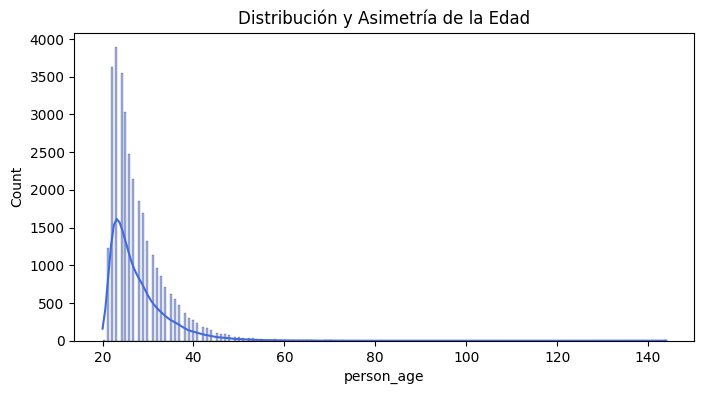

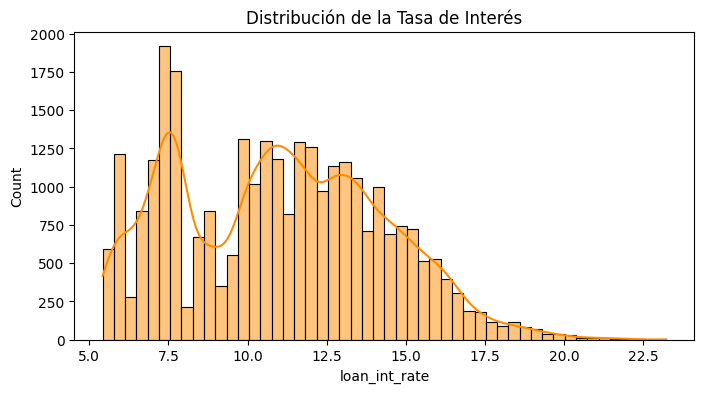

In [19]:
# Gráfica para la Edad
plt.figure(figsize=(8, 4))
sns.histplot(data=credit_df, x='person_age', kde=True, color='royalblue')
plt.title('Distribución y Asimetría de la Edad')

# Gráfica para la Tasa de Interés
plt.figure(figsize=(8, 4))
sns.histplot(data=credit_df, x='loan_int_rate', kde=True, color='darkorange')
plt.title('Distribución de la Tasa de Interés')

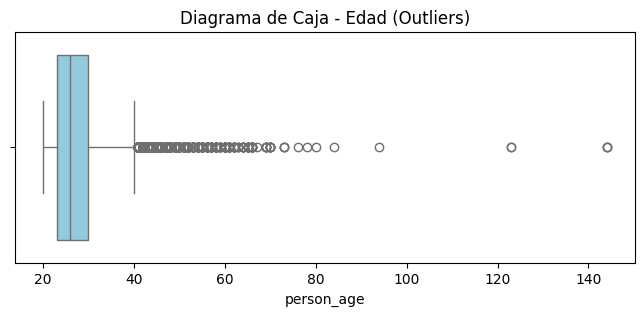

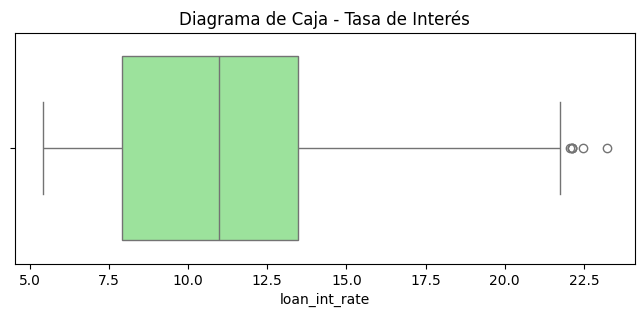

In [20]:
# Boxplot para la Edad (aquí verás el punto de 144 flotando a la derecha)
plt.figure(figsize=(8, 3))
sns.boxplot(data=credit_df, x='person_age', color='skyblue')
plt.title('Diagrama de Caja - Edad (Outliers)')
plt.show()

# Boxplot para la Tasa de Interés
plt.figure(figsize=(8, 3))
sns.boxplot(data=credit_df, x='loan_int_rate', color='lightgreen')
plt.title('Diagrama de Caja - Tasa de Interés')
plt.show()

Con esto podemos observar que los datos `person_age` y `loan_int_rate` tienen una concentracion mayor en las personas jovenes, como lo vimos en los resultados la `media` de personas a las que se les aprueba un prestamo es de **26 años** con un monto de aproximadamente de **$8,000**.

Ademas se nota un error claro ademas de tener algunas celdas vacias tenemos como valor maximo a una persona con una edad de **144 años**, la cual practicamente es imposible, lo que hace que los valores de estas dos variables de `person_age` y `loan_int_rate` se distorcienen un poco y no solo estas si no tambien algunas otras se ven afectadas.

En cunto a la edad tiene un asimetria positiva con un valor de 2.58 osea que su cola va hacia la derecha y curtosis leptocúrtica con 18.56 lo que nos dice que su distribucion es mayor a 3. Como se menciono antes se concentra en los jovenes y la cola larga a los valores tipicos, como la edad de 144 que se encontro.

Por otra parte la tasa de prestamo comparada con la anterior no tiene un pico agudo y es mas centrada con una asimetria simetrica de 0.21 y curtosis platicúrtica de -0.67, lo que nos dice que los datos aqui si estan distribuidos de una forma mas pareja hacia ambos lados osea una distribucion negativa alrededor de 0.

------

4. Utiliza histogramas para determinar la distribución de los valores representados en cada variable.
*   ¿Se corresponde con lo obtenido en el cálculo de asimetría? Como verás, los datos reales son más complejos que la teoría. Por esta razón, recuerda siempre acompañar el análisis de la asimetría con algún gráfico como un histograma.

**NOTA**. Para esto también puedes ocupar los gráficos `kde` ([kernel density estimation](https://www.cienciadedatos.net/documentos/pystats02-kernel-density-estimation-kde-python.html)) que crean una curva continua y suave expandiendo la idea del histograma.

<font color="orange">AGREGA LA RESPUESTA A LA PREGUNTA AQUI</FONT>

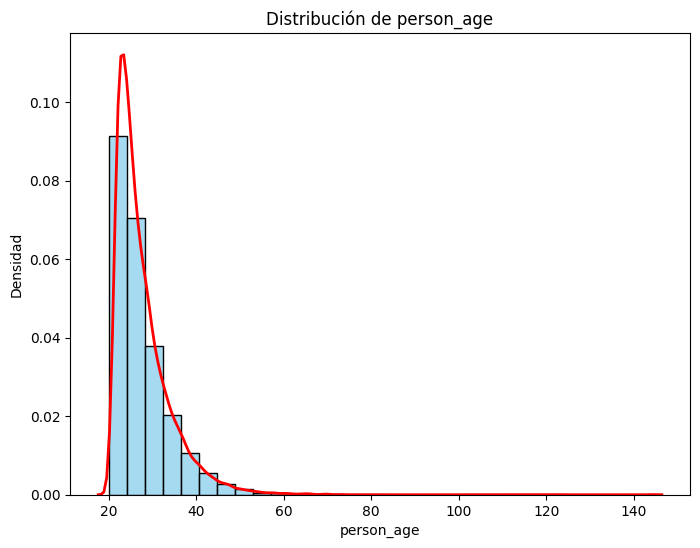

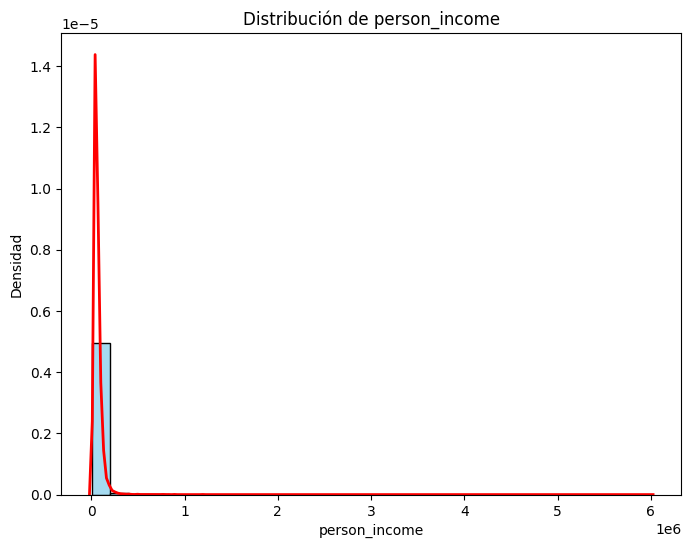

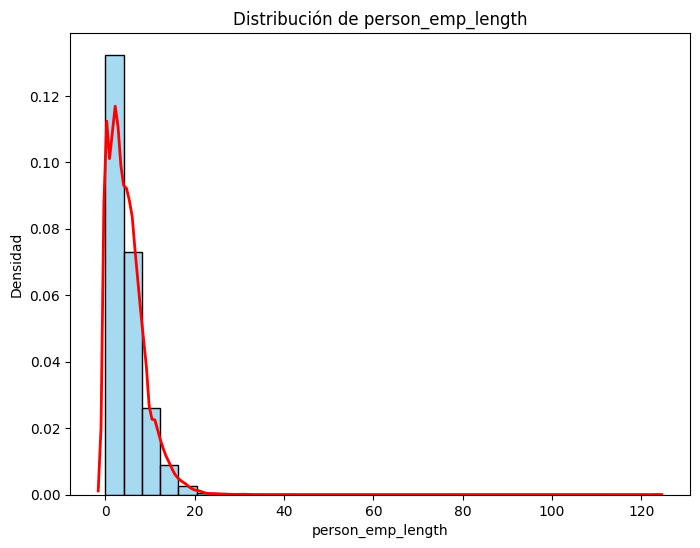

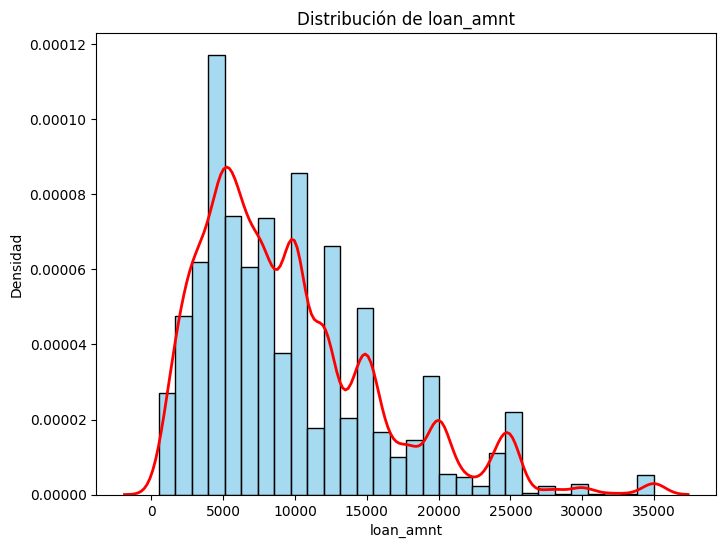

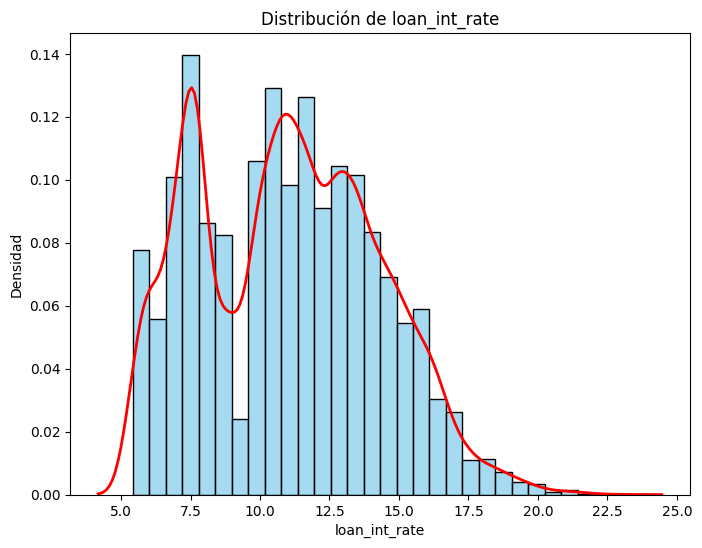

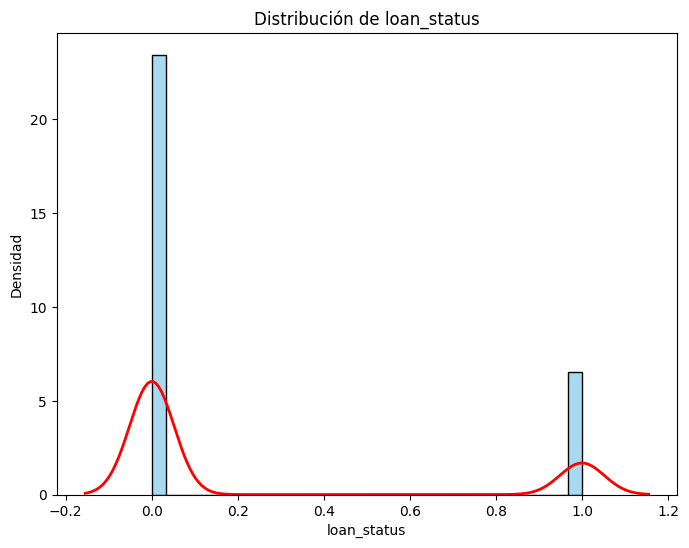

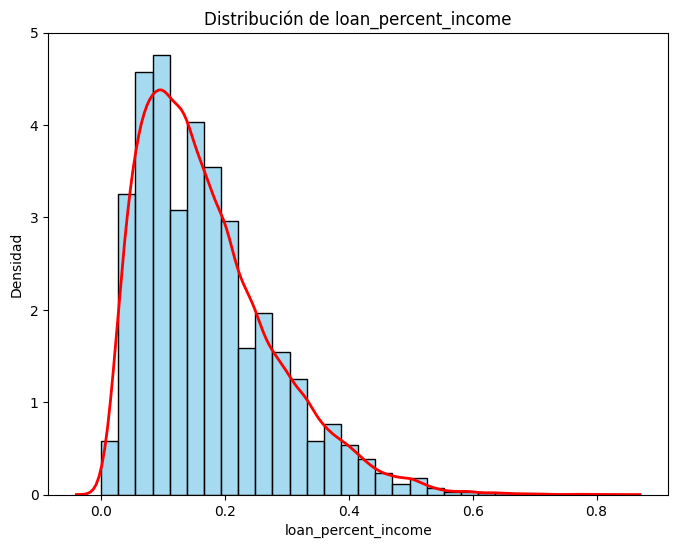

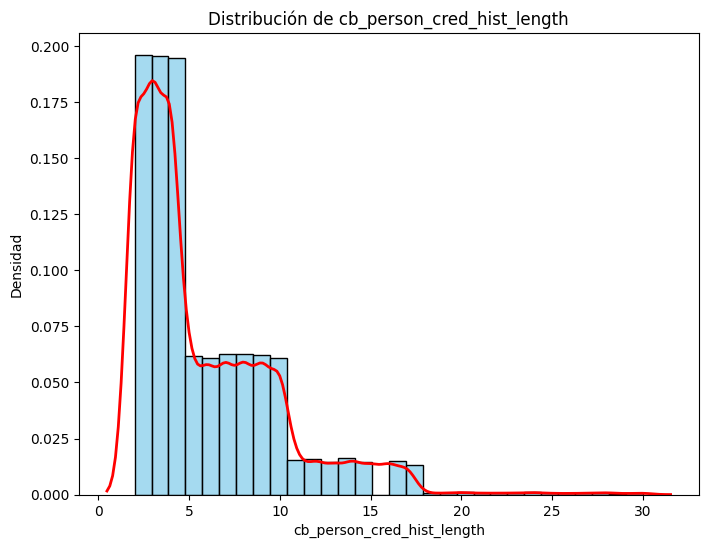

In [21]:
for i in credit_df.select_dtypes('number'):
    plt.figure(figsize=(8, 6))

    sns.histplot(
        data=credit_df,
        x=i,
        bins=30,
        stat='density',
        color='skyblue'
    )

    sns.kdeplot(
        data=credit_df,
        x=i,
        color='red',
        linewidth=2
    )

    plt.title(f'Distribución de {i}')
    plt.xlabel(i)
    plt.ylabel('Densidad')
    plt.show()

Lo que podemos apreciar aqui en los histogramas en cada uno es como se comento en el apartado anterior lo resultados o valores se enfocan mas en las edades jovenes, aunque el desfase de algunos resultados tambien se debe a datos faltantes y datos como el de la edad maxima de **144 años**, pero igual gracias a KDE o mas explicitamnete la funcion de `sns.kdplot` podemos observar como se comporta cada uno de los histogramas y la tendencia que tiene el mismo.

En conclusion los datos se centran en personas de entre 26 a 30 años que son representados tambien por la mediana, desfansando en algunas zonas que es donde se estira la linea esto confirmando la asimetria positiva, y algunos errores o valores atitpicos que se detectaron.

----

5. Emplea boxplots para mostrar la distribución de los datos a través de sus cuartiles.

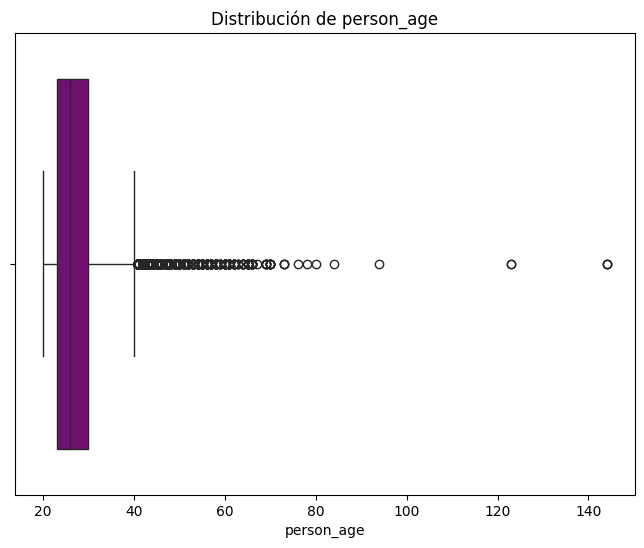

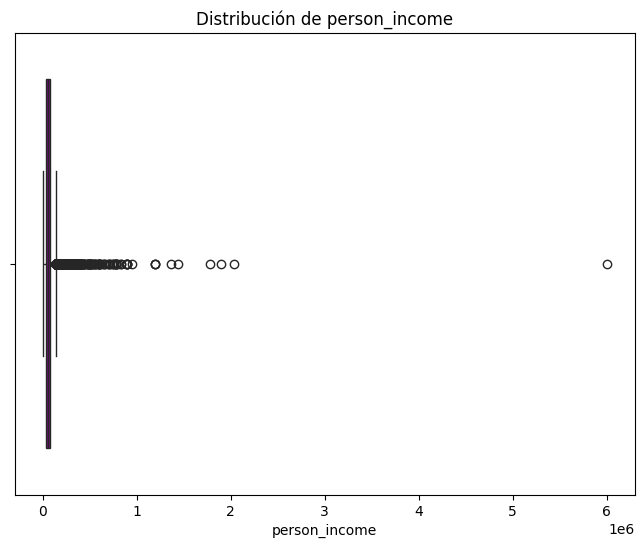

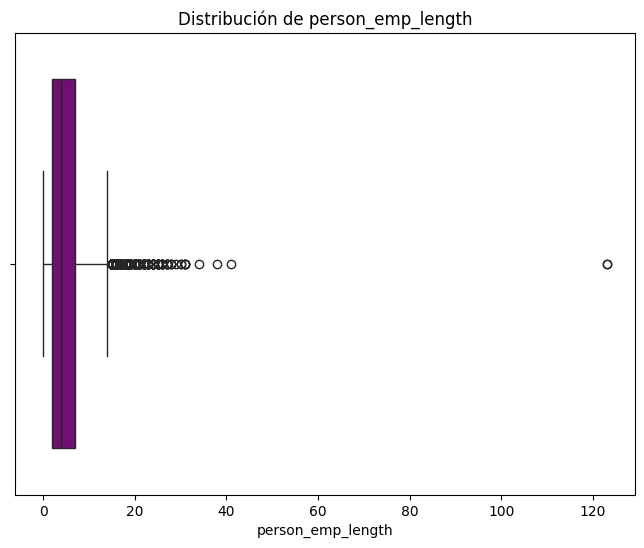

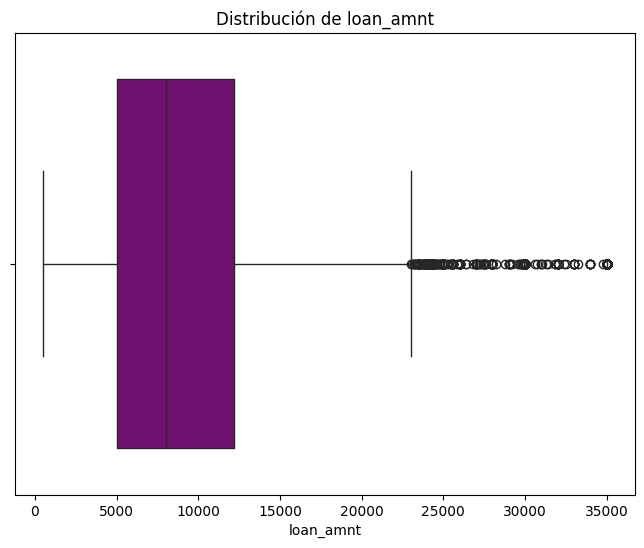

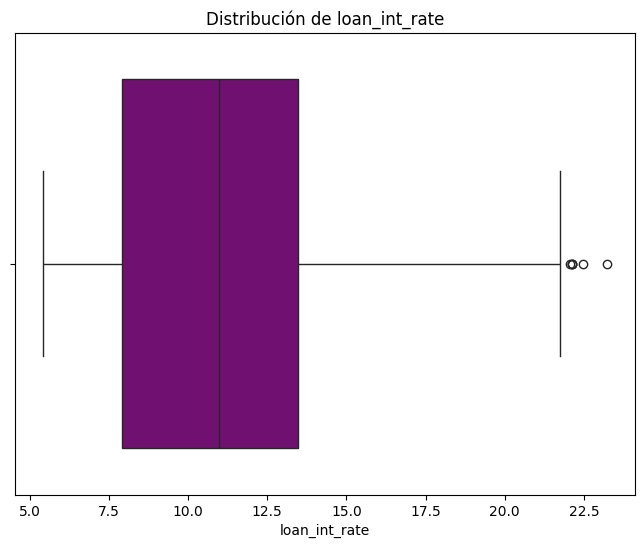

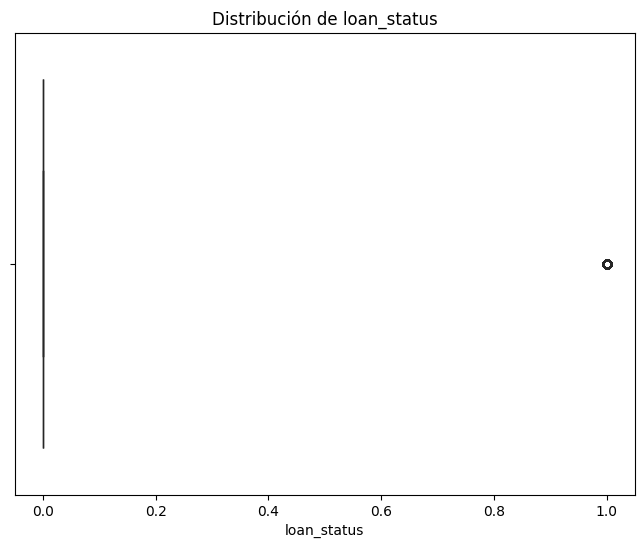

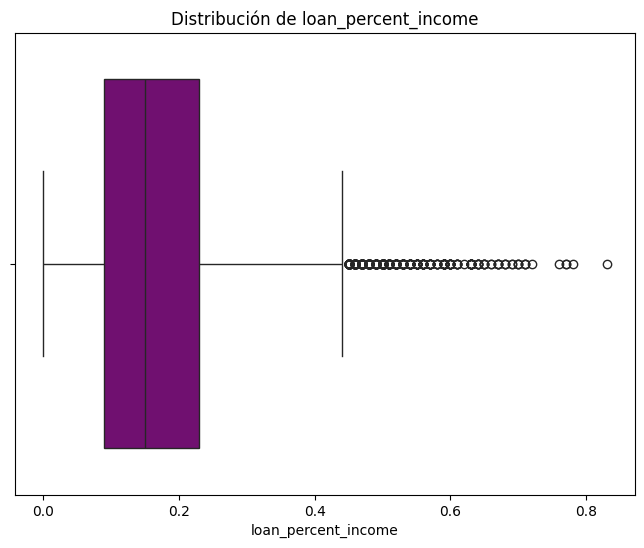

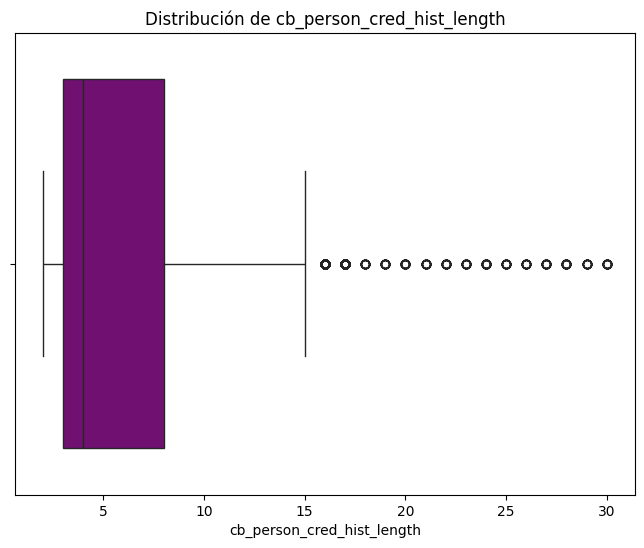

In [22]:
for i in credit_df.select_dtypes('number'):
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        data=credit_df,
        x=i,
        color='purple',
        showfliers=True)

    plt.title(f'Distribución de {i}')
    plt.xlabel(i)

-----

Como se puede ver la mayoria de las variables en funcion de los cuartiles estan en el `Q2 - Q3` que es el que representa la `Mediana`, vemos de igual que entre el `Q1 - Q2` exite una cantidad de datos considerable pero no tanto como la anterior mencionada.

Estos datos representan un aproximado entre la edad de 26 - 30 años en total, asi mismo al final de la linea podemos ver el valor maximo en cada una de las variables y al inicio el valor minimo.

Podemos ver que hay varios si no es que en su mayoria todos los histogramas tienen bastantes valores atipicos, lo cuales se representan con los circulos de color negro.

*   Como podrás observar hay valores atípicos en todas las variables. Ejecuta el siguiente código para identificar los valores atípicos en la variable `person_age`

**Interpretación Resultados**

<FONT COLOR="ORANGE">AGREGA AQUI LA INTERPRETACION DE TUS RESULTADOS</FONT>

Podemos ver que los datos atipicos en cuestion de realismo comienza con una persona que tiene 123 años de edad hasta el que tiene 144 años de edad.

En total tenemos 5 datos que son atipicos, el cual pues no concuerda en un entorno realista ya que no existen personas ni de 123 o de 144 años de edad.

Valores atipicos exactos [123, 123, 144 ,144 ,144]

In [23]:
#COMENTE CADA LINEA DE CODIGO EXPLICANDO SU USO

percentile_25 = credit_df["person_age"].quantile(0.25)
percentile_75 = credit_df["person_age"].quantile(0.75)

iqr = percentile_75 - percentile_25

upper_limit = percentile_75 + 1.5 * iqr
lower_limit = percentile_25 - 1.5 * iqr

IQR_outliers = credit_df[(credit_df["person_age"] < lower_limit) | (credit_df["person_age"] > upper_limit)]
IQR_outliers

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
29121,50,900000,MORTGAGE,11.0,DEBTCONSOLIDATION,B,30000,12.69,0,0.03,N,15
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


-----

# Análisis de variables de texto

 6. Obtén las siguientes estadísticas descriptivas para todas las variables de texto:
*   Tendencia central (moda)
*   Cardinalidad (cantidad de valores únicos)
*   Recuentos únicos (número de ocurrencias para cada valor único)

**NOTA**. Un resumen de estas estadísticas, puedes obtenerlas indicando en la función `describe()` que se incluirán sólo las variables de tipo object: `describe(include = 'object')`. Para los recuentos utiliza la función `df['columna'].value_counts()`

In [24]:
#IDENTIFIQUE CUALES SON LAS VARIABLES DE TEXTO
credit_df.select_dtypes('object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
...,...,...,...,...
32576,MORTGAGE,PERSONAL,C,N
32577,MORTGAGE,PERSONAL,A,N
32578,RENT,HOMEIMPROVEMENT,B,N
32579,MORTGAGE,PERSONAL,B,N


In [25]:
credit_df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [26]:
#AGREGUE TODAS LAS CELDAS DE TEXTO Y CODIGO QUE NECESITE
credit_df.select_dtypes('object').mode()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,EDUCATION,A,N


In [27]:
credit_df.select_dtypes('object').nunique()

,0
person_home_ownership,4
loan_intent,6
loan_grade,7
cb_person_default_on_file,2


In [28]:
credit_df.select_dtypes('object').value_counts()

person_home_ownership  loan_intent        loan_grade  cb_person_default_on_file
RENT                   MEDICAL            B           N                            1208
                       EDUCATION          B           N                            1069
MORTGAGE               EDUCATION          A           N                            1047
                       PERSONAL           A           N                             986
                       DEBTCONSOLIDATION  A           N                             974
                                                                                   ... 
RENT                   DEBTCONSOLIDATION  G           Y                               1
                       HOMEIMPROVEMENT    G           N                               1
                       EDUCATION          G           Y                               1
                       PERSONAL           G           N                               1
                       VENTURE            G           N                               1
Name: count, Length: 245, dtype: int64

Como se muestra en la funcion de la moda, las personas que mas solicitan un prestamo son personas que viven en una casa de renta, que su proposito principal es la educacion, con una calificacion de prestamo excelente (A) y sin incumplimientos anteriores, lo que hace match con la informacion anterior de los numeros ya que al tratarse de personas jovenes de entre 26-30 años pueden ser estudiantes universitarios que viven en departamentos de renta y necesitan el dinero para seguir con su educacion.

-----

7. Utiliza gráficos de barras por variable para representar la frecuencia de cada categoría.

**NOTA**. seaborn posee un gráfico de recuento, para variables de tipo object, que calcula la frecuencia de cada categoría sin necesidad de utilizar la función `value_counts()`. Para generarlo debes indicar la columna: `sns.countplot(x='columna', data=df) `

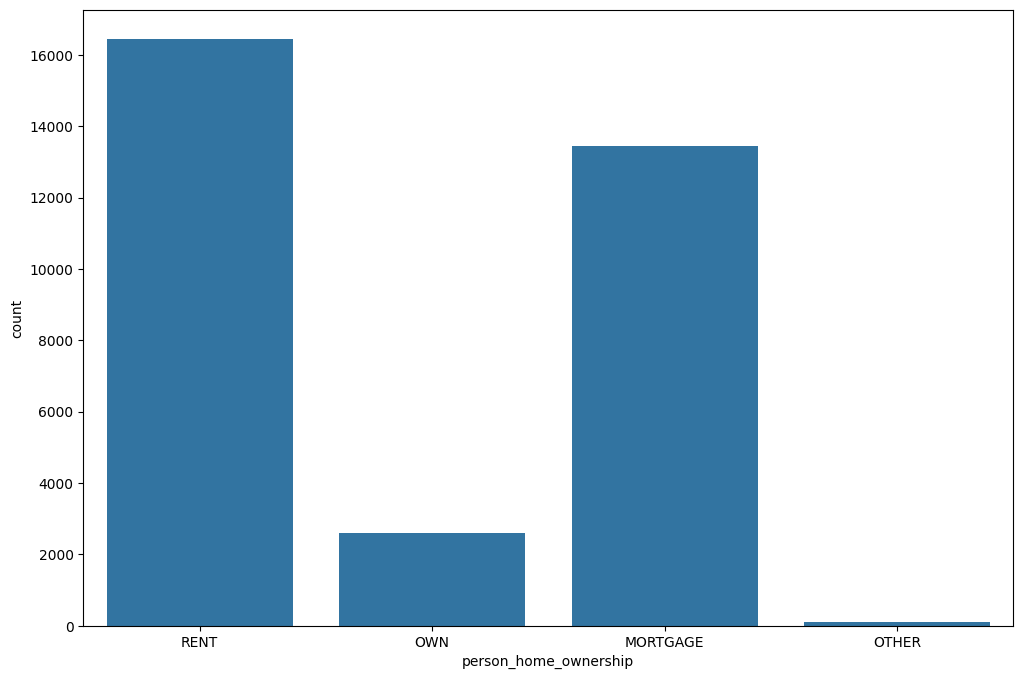

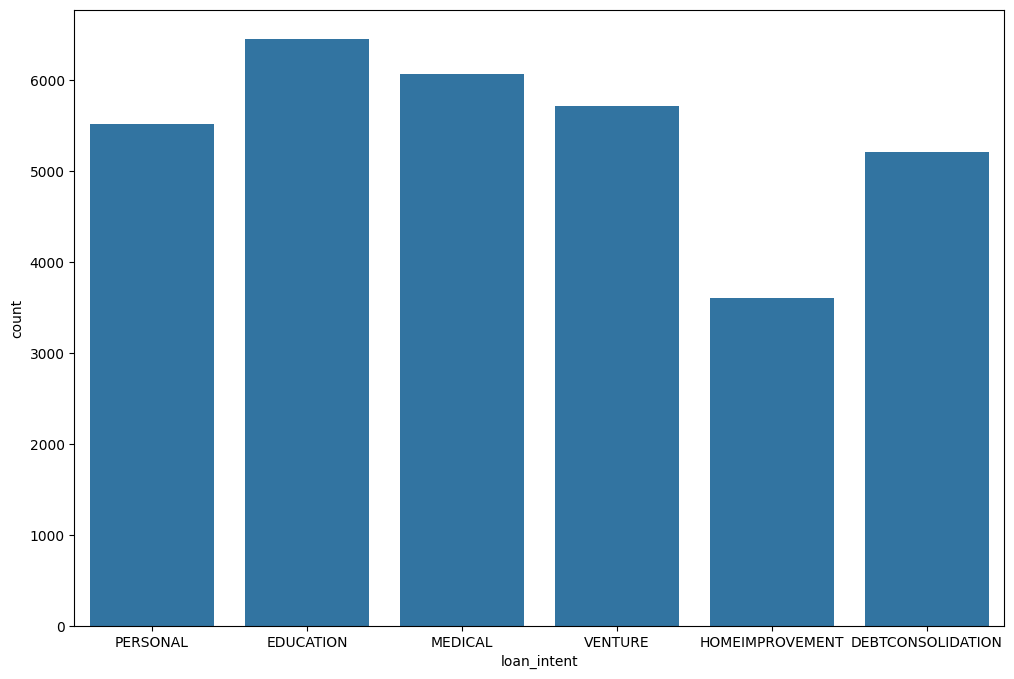

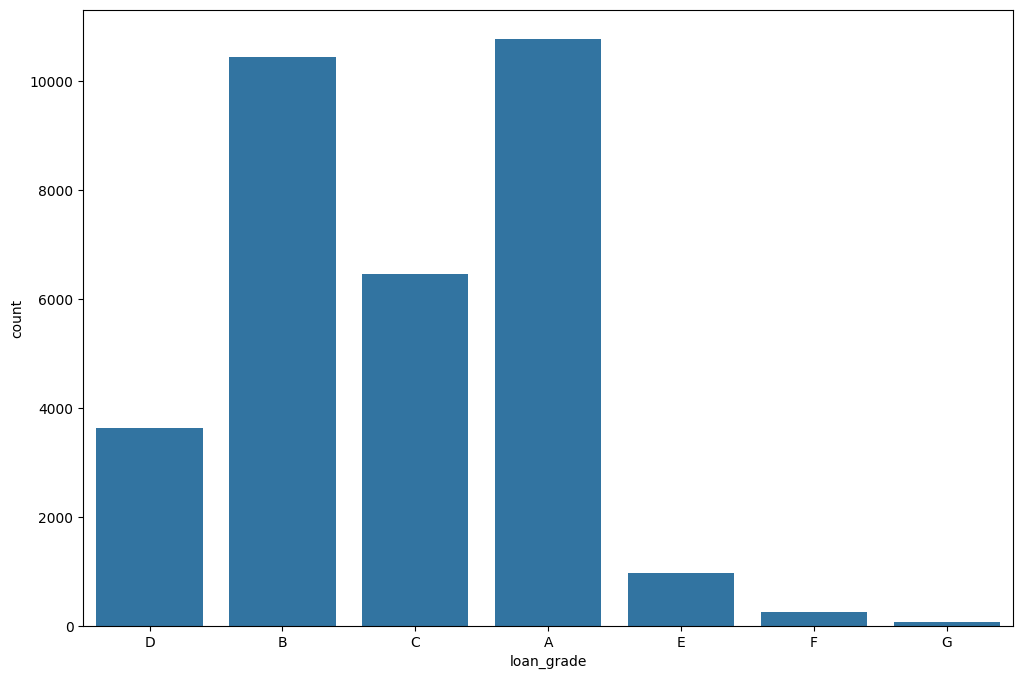

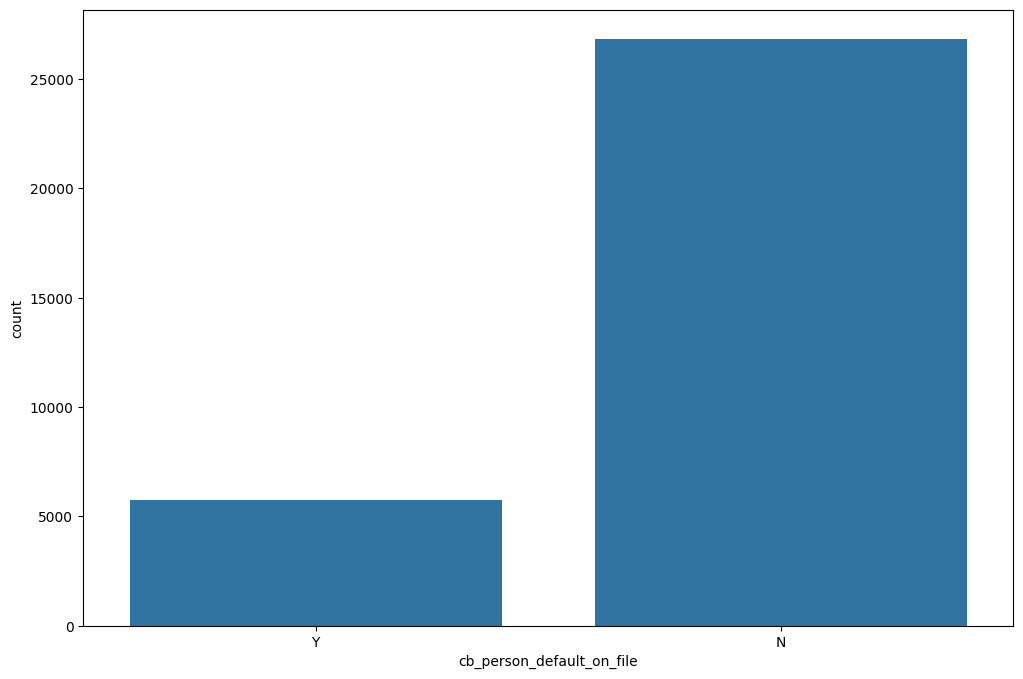

In [29]:
#AGREGUE TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITE
for i in credit_df.select_dtypes('object'):
    plt.figure(figsize=(12, 8))
    sns.countplot(x=i, data=credit_df)

-----

Analisando las graficas de barras anteriores se puede determinar lo sigueinte en cada una respectivamente:
1. Que la mayor gente que pide un prestamo tiene una casa de renta
2. Que el motivo principal del prestamo es por educacion o medico
3. El riesgo crediticio es bajo donde predominan A y B que son los de menor riesgo
4. Y que las personas mayormente no tienen un historial de incumplimiento

# **Parte 2**. Análisis de correlación (bivariante y multivariante)

La variable `loan_status` será la variable de salida (o a predecir en un modelo de ML). Analiza su relación con el resto de las variables a través de los siguientes gráficos:

8. Un box plot para visualizar la distribución de `loan_percent_income` según el `loan_status`. Interpreta el resultado.

Text(0, 0.5, 'Porcentaje del ingreso del solicitante')

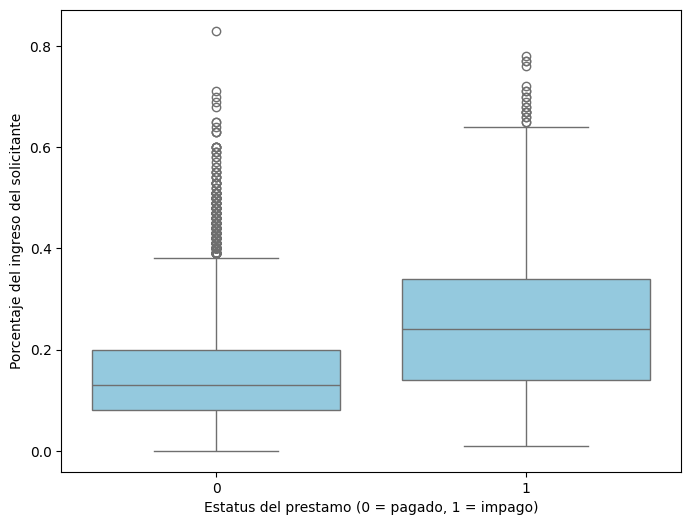

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=credit_df, x='loan_status', y='loan_percent_income', color='skyblue')
plt.xlabel('Estatus del prestamo (0 = pagado, 1 = impago)')
plt.ylabel('Porcentaje del ingreso del solicitante')

**Interpretación resultados**

<FONT COLOR="ORANGE">AGREGUE AQUI SU RESPUESTA</FONT>

Se puede apreciar que las personas que cumplen con su pago tienden a ser a las que menos se les resta de sus ingresos, es decir, que del apgo que reciben se les resta un porcentaje mejor de entre 10% a 18% de acuerdo a lo que representa la grafica.

Por otro lado vemos que las personas que tienen un incumplimiento que como se nota la caja es mayor ya que hay mayor incumplimiento pero esto debido a que el porcentaje que se le quitan los ingresos es mayor ya que de entre el 16% a un 35% aproximadamente lo que tal ves genere un incumplimiento de pago mayor derivado de diversos motivos.

 9. En los gráficos de barras que obtuviste en el ejercicio 7, separa el conteo según el `load_status`, utilizando el parámetro `hue`.

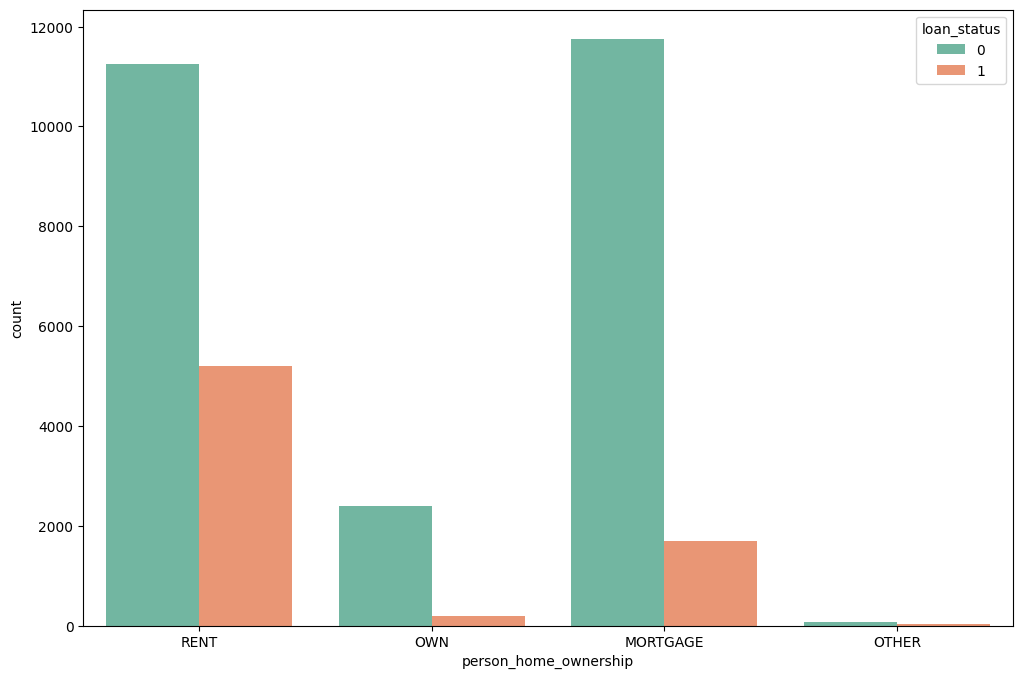

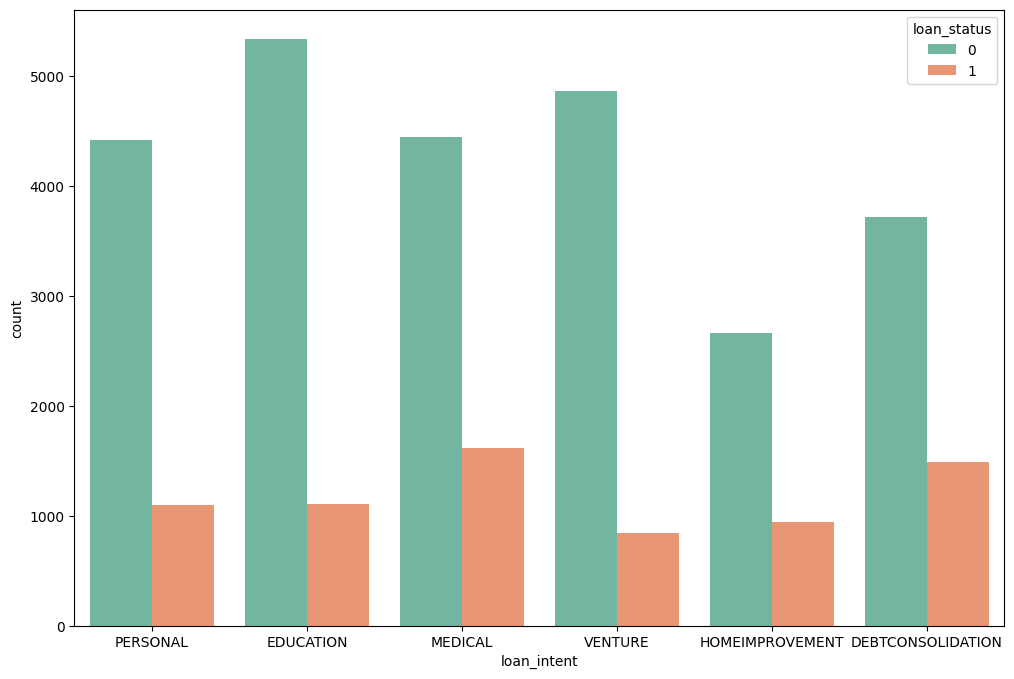

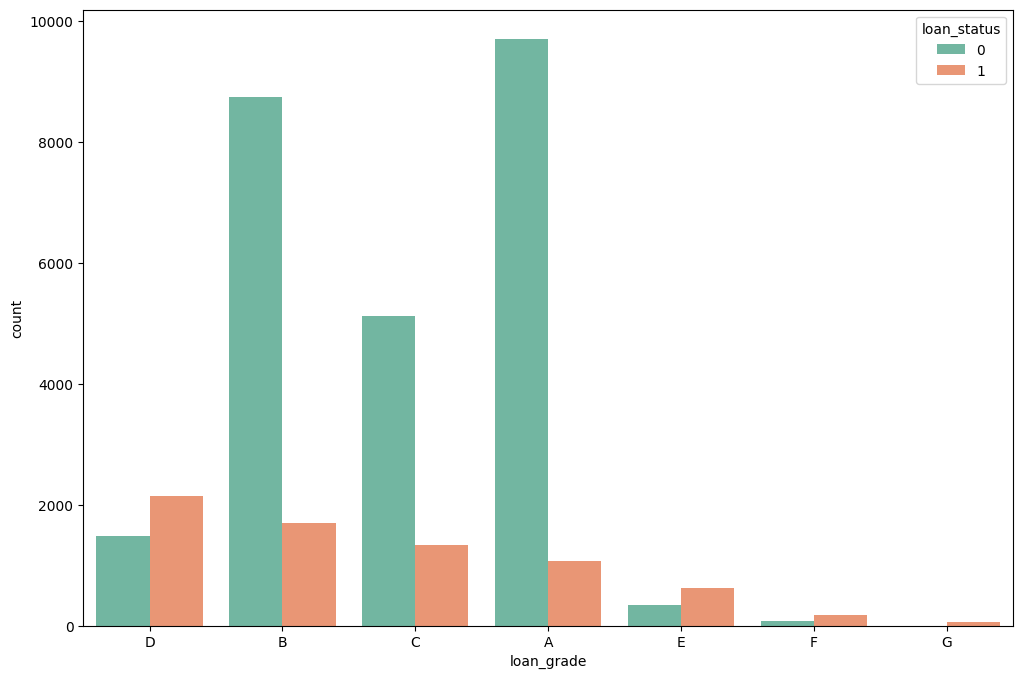

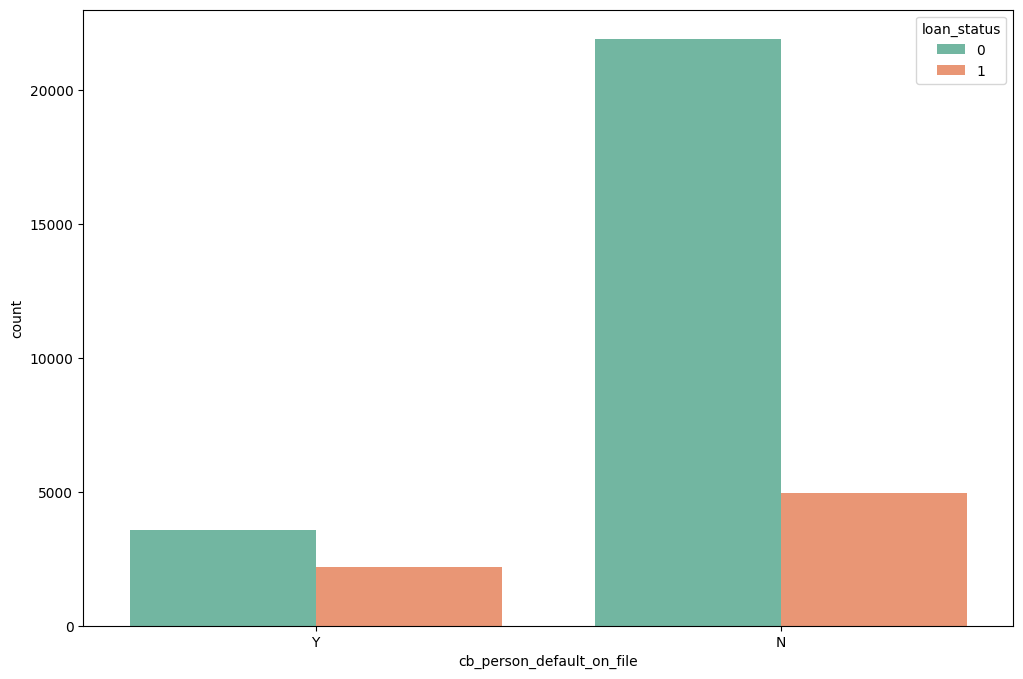

In [45]:
for i in credit_df.select_dtypes('object'):
    plt.figure(figsize=(12, 8))
    sns.countplot(
        x=i,
        data=credit_df,
        hue='loan_status',
        palette='Set2')

Lo que se puede observar en las anteriores graficas es casi casi lo que vimos en la de bigote de arriba pero con variables distintas, pero en terminos concretos las personas que piden un prestamo mucho mas grande de lo que pudiera pagar tiene un mayor riesgo de no pagarlo mientras que las personas que piden prestamos mas accesibles y acorde a su sueldo suelen pagar con exito.

10. Un mapa de calor con los valores de correlación de todas las variables del dataframe.
*   ¿Qué variable tiene mayor correlación con `loan_status`?

**Respuesta a pregunta**

<FONT COLOR="ORANGE">AGREGUE SU RESPUESTA AQUI</FONT>

La variable que mas correlacion tiene con `loan_status` es la de `loan_percent_income` ya que una representa el estado del prestamo y la otra representa el porcentaje del ingreso en base al prestamo, dejando un `0.38` el cual es lo mas cercano que tiene esa variable en una correlacion mayor.

<Axes: >

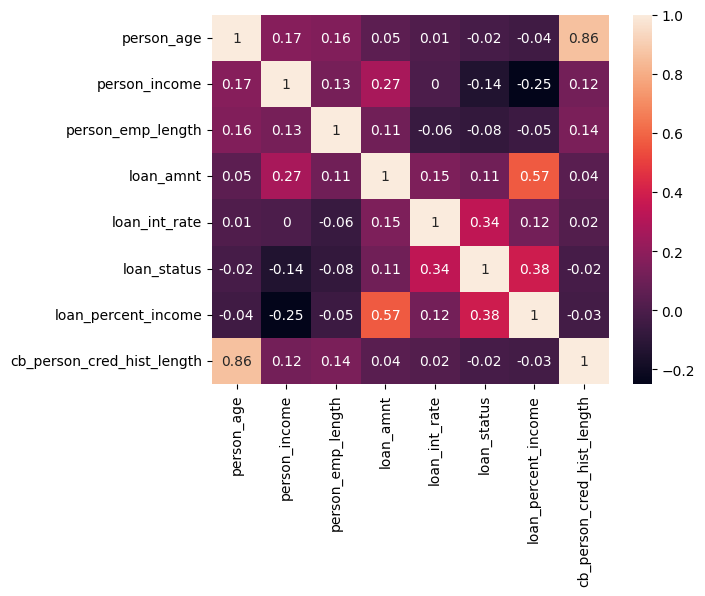

In [52]:
sns.heatmap(round(credit_df.corr(numeric_only=True),2), annot=True)